In [2]:
import pandas as pd
import numpy as p
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('C:/Users/pinki/OneDrive/Desktop/Machine_learning_indetails/dataset/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
le = LabelEncoder()
df['Gender_Id'] = le.fit_transform(df['Gender'])

In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Gender_Id'],
      dtype='object')

In [6]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Id']

In [7]:
df = df[features]

### Features

In [8]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Id']]


In [9]:
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)

### Elbow Method

In [10]:
error_rate = []
k_range = range(1, 21)

In [11]:
for i in k_range:
    kmean = KMeans(n_clusters = i)
    kmean.fit_predict(X_scale)
    error_rate.append(kmean.inertia_)

Text(0.5, 1.0, 'Elbow Method - Choosing Optimal Number of Clusters')

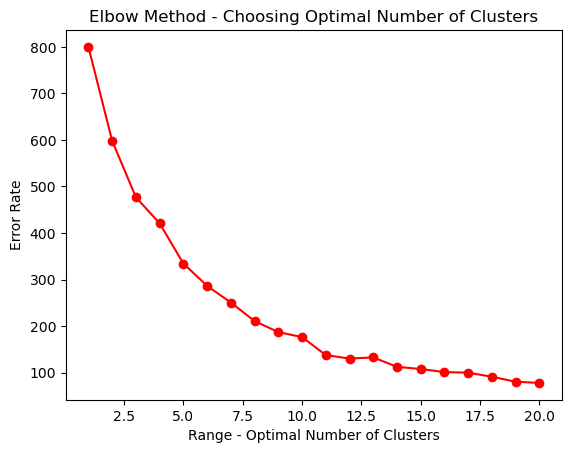

In [12]:
plt.plot(k_range, error_rate, color='red', marker='o')
plt.xlabel('Range - Optimal Number of Clusters')
plt.ylabel('Error Rate')
plt.title('Elbow Method - Choosing Optimal Number of Clusters')

In [13]:
k = 5
model = KMeans(n_clusters=k)
clusters = model.fit_predict(X_scale)
df['clusters'] = clusters

In [14]:
df

,Age,Annual Income (k$),Spending Score (1-100),Gender_Id,clusters
0,19,15,39,1,3
1,21,15,81,1,3
2,20,16,6,0,4
3,23,16,77,0,4
4,31,17,40,0,4
...,...,...,...,...,...
195,35,120,79,0,1
196,45,126,28,0,1
197,32,126,74,1,1
198,32,137,18,1,2


In [15]:
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], hue=clusters, palette='viridis')
plt.close()

In [16]:
cluster = model.labels_
df['cluster'] = cluster

In [17]:
pair_plot = df

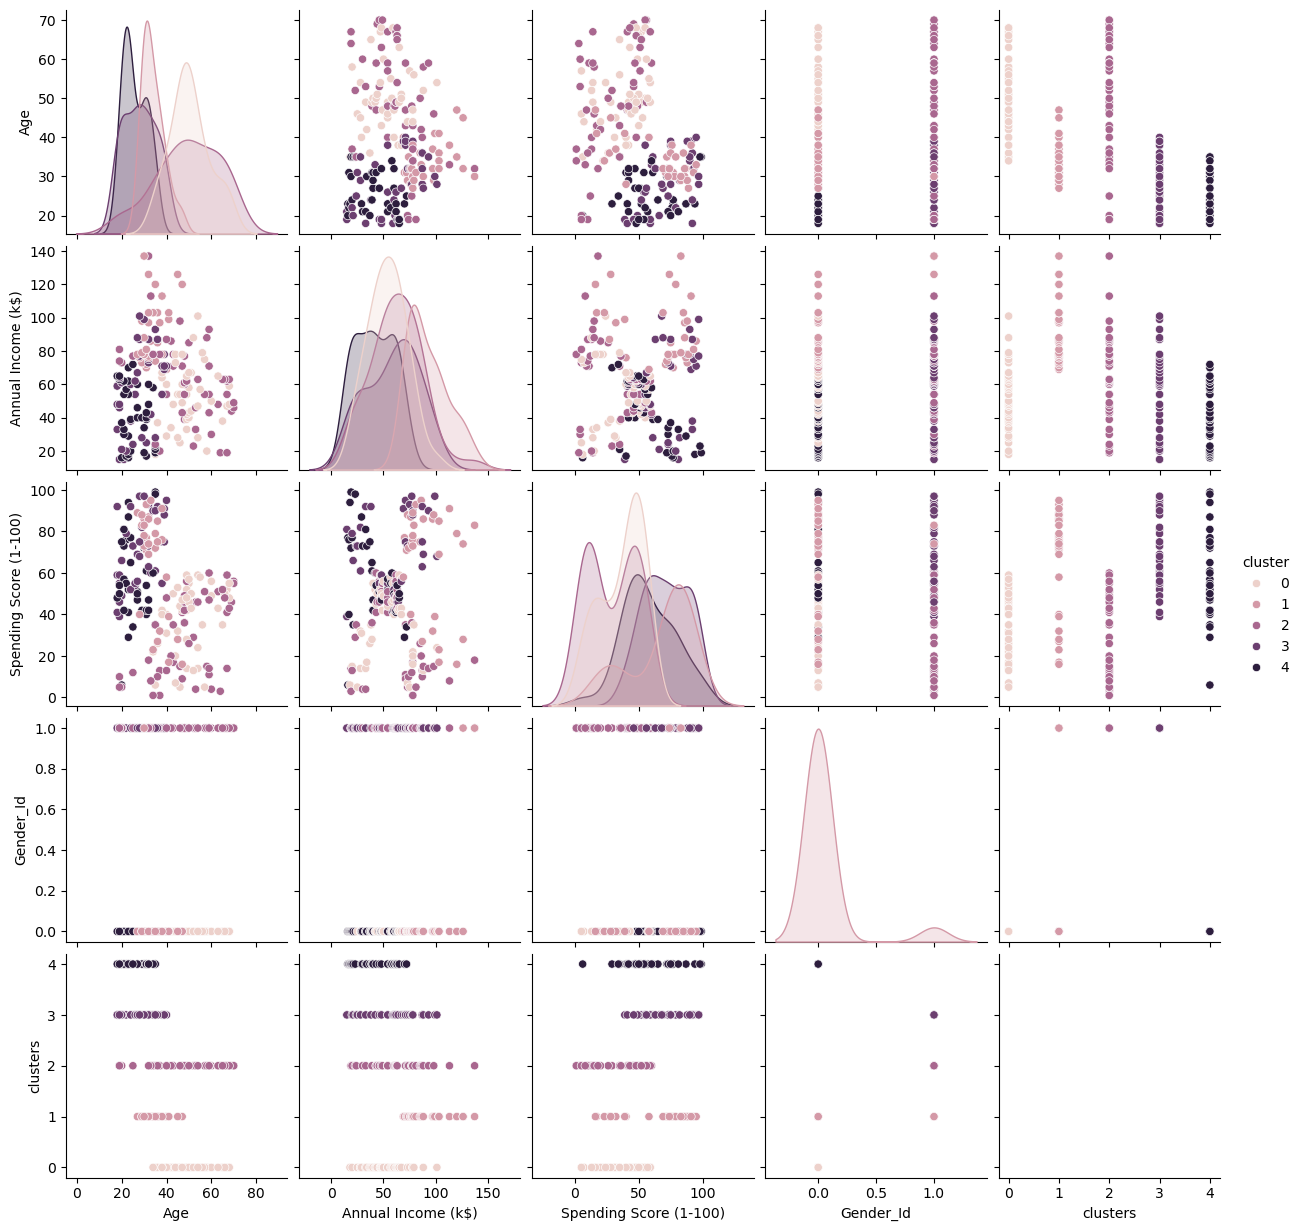

In [18]:
sns.pairplot(
    pair_plot,
    hue='cluster'
)
plt.savefig('pp.png')

In [19]:
# total_customer = df.groupby('cluster')['CustomerID'].count().reset_index()
# total_customer

In [20]:
# covariance
# principle componenet analysis
# dimensity reduction

In [21]:
from sklearn.decomposition import PCA

In [22]:
pca = PCA(n_components=len(features))


In [23]:
# covariance calculation

In [24]:
X_pca = pca.fit_transform(X_scale)

In [25]:
X_pca

array([[-4.06382715e-01, -5.20713635e-01,  2.07252663e+00,
        -1.33552903e+00],
       [-1.42767287e+00, -3.67310199e-01,  2.27764369e+00,
        -8.23287388e-02],
       [ 5.07605706e-02, -1.89406774e+00,  3.67375232e-01,
        -2.17438112e+00],
       [-1.69451310e+00, -1.63190805e+00,  7.17466691e-01,
        -7.52284957e-02],
       [-3.13108383e-01, -1.81048272e+00,  4.26459924e-01,
        -6.83070448e-01],
       [-1.71744627e+00, -1.59926418e+00,  6.96379423e-01,
        -1.53191637e-01],
       [ 7.90821124e-01, -1.94727112e+00,  1.86491593e-01,
        -1.41185800e+00],
       [-2.14832159e+00, -1.50537369e+00,  7.58463596e-01,
         3.91407991e-01],
       [ 2.77428623e+00, -8.82987672e-01,  1.38814112e+00,
        -3.55576076e-02],
       [-1.21629477e+00, -1.61640464e+00,  5.55769702e-01,
         1.44050713e-01],
       [ 2.62905084e+00, -8.61237043e-01,  1.42011358e+00,
         4.18453647e-01],
       [-1.68947038e+00, -1.54542784e+00,  6.55007647e-01,
      

In [34]:
loadings= pd.DataFrame(pca.components_,
                       index =features,
                       columns=[f'pc{i+1}' for i in range(len(features))])
loadings

,pc1,pc2,pc3,pc4
Age,0.687900,-0.006082,-0.686920,0.234302
Annual Income (k$),-0.103690,0.765252,0.103211,0.626886
Spending Score (1-100),-0.122384,-0.643667,0.136573,0.743009
Gender_Id,0.707859,0.006721,0.706283,-0.007405


In [ ]:
loading = pd.DataFrame(pca.components_,
                       index = features,
                       columns = [f'pc{i+1}' for i in range(len(features))])

In [28]:
# X_axis -> age,gender id
# Y_axis -> annual income, spending score

In [35]:
df.columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Id',
       'clusters', 'cluster'],
      dtype='object')

In [41]:
col= 'Annual Income (k$)'

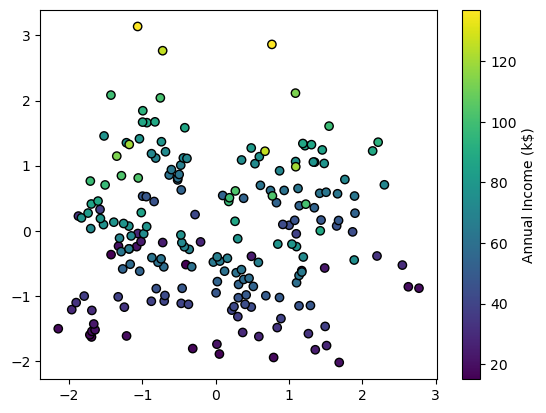

In [46]:

scatter  =plt.scatter(x=X_pca[:, 0], y=X_pca[:, 1], c = df[col], edgecolor='black')
plt.colorbar(scatter,label = col)
plt.xlabel = ('principle component 1')
plt.xlabel = ('principle component 2')